In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import albumentations as A
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

C:\Users\corra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
annot_dir = "C:/Users/corra/Desktop/University/datasets/maskDetection/annotations/"#Percorso etichette
img_dir = "C:/Users/corra/Desktop/University/datasets/maskDetection/images/"#Percorso immagini non processate
dataset_dir = "C:/Users/corra/Desktop/University/datasets/maskDetection/"#Percorso a cui va concatenato il nome di una delle 3 classi che rappresenta la cartella con le rispettive immagini

In [ ]:
#Parsing dei file XML delle annotazioni.
#Per ogni file .xml, estrae: nome immagine, coordinate bounding box e label di ogni volto rilevato.

def extract_data(annot_dir):
    data=[]
    for filename in os.listdir(annot_dir):
        if not filename.endswith('.xml'): continue
        
        path = os.path.join(annot_dir, filename)
        tree = ET.parse(path)
        root = tree.getroot()

        # Estrazione nome file immagine
        img_name = root.find('filename').text
        
        for obj in root.findall('object'):
            label = obj.find('name').text
            
            # Estrazione coordinate bounding box
            bbox = obj.find('bndbox')
            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)
            
            data.append({
                'image': img_name,
                'label': label,
                'xmin': xmin, 'ymin': ymin,
                'xmax': xmax, 'ymax': ymax
            })

    return data

data = extract_data(annot_dir)
print(data[0])

{'image': 'maksssksksss0.png', 'label': 'without_mask', 'xmin': 79, 'ymin': 105, 'xmax': 109, 'ymax': 142}


In [ ]:
#Crop dei volti dalle immagini originali usando le bounding box.

#Codifica classi:
#1 = without_mask
#2 = mask_weared_incorrect
i0=i1=i2=0
for i in range(len(data)):
    img = cv2.imread(img_dir+data[i]["image"])
    img_crop = img[data[i]["ymin"]:data[i]["ymax"], data[i]["xmin"]:data[i]["xmax"]]
    img_crop = cv2.resize(img_crop, (64, 64))
    if (data[i]["label"] == "with_mask"):
        cv2.imwrite(dataset_dir+"with_mask/with_mask"+str(i0)+".png", img_crop)
        i0+=1
    if (data[i]["label"] == "without_mask"):
        cv2.imwrite(dataset_dir+"without_mask/without_mask"+str(i1)+".png", img_crop)
        i1+=1
    if (data[i]["label"] == "mask_weared_incorrect"):
        cv2.imwrite(dataset_dir+"mask_weared_incorrect/mask_weared_incorrect"+str(i2)+".png", img_crop)
        i2+=1

In [ ]:
#Pipeline di data augmentation: 3 trasformazioni diverse per aumentare la varietÃ  del dataset.

#Pipeline 1: trasformazioni geometriche (rotazione, traslazione, flip)
transform = A.Compose([
    A.Rotate(limit=45, p=0.5),  # Rotazione casuale tra -45 e 45 gradi
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0, rotate_limit=0, p=0.5),  # Traslazione casuale
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),  # Variazione luminositÃ /contrasto
    A.HorizontalFlip(p=0.3),  # Specularizzazione orizzontale
])

#Pipeline 2: trasformazioni colorimetriche e rumore
transform2 = A.Compose([
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),  # Variazione tonalitÃ  colore
    A.GaussNoise(std_range=(0.1, 0.15), p=0.3),  # Aggiunta rumore gaussiano
    A.MotionBlur(blur_limit=3, p=0.2),  # Effetto movimento
])

#Pipeline 3: occlusion e distorsione ottica
transform3 = A.Compose([
    A.CoarseDropout(max_holes=3, max_height=4, max_width=12, min_holes=1, p=0.5),  # Occlusioni artificiali
    A.OpticalDistortion(distort_limit=0.1, shift_limit=0.1, p=0.3),  # Distorsione lente
])

In [ ]:
i=0
for root, dir, files in os.walk(dataset_dir+"/without_mask"):
    for file in files:
        img = cv2.imread(dataset_dir+"/without_mask/"+file)
        imgp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        aug = transform(image=imgp)  #Cambia trasformazione per ulteriore data augmentation
        img_aug = aug["image"]
        img_aug = cv2.cvtColor(img_aug, cv2.COLOR_RGB2BGR)
        cv2.imwrite(dataset_dir+"/without_mask/img_aug_opt"+str(i)+".png", img_aug)
        i+=1


In [ ]:
#Caricamento immagini da ciascuna cartella di classe.
#Pre-processing: conversione BGR->RGB e normalizzazione [0,1].

#Classe 0: with_mask (max 1500 per bilanciamento)
imgs=[]
for root, dir, files in os.walk(dataset_dir+"/with_mask"):
    for file in files:
        img = cv2.imread(dataset_dir+"/with_mask/"+file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_array = img_to_array(img)
        img_array = img_array / 255.0
        imgs.append(img_array)
        if len(imgs)>1499:
            break
df_A = pd.DataFrame({
    'img': imgs,
    'label': 0
})

#Classe 1: without_mask
imgs=[]
for root, dir, files in os.walk(dataset_dir+"/without_mask"):
    for file in files:
        img = cv2.imread(dataset_dir+"/without_mask/"+file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_array = img_to_array(img)
        img_array = img_array / 255.0
        imgs.append(img_array)
df_B = pd.DataFrame({
    'img': imgs,
    'label': 1
})

#Classe 2: mask_weared_incorrect
imgs=[]
for root, dir, files in os.walk(dataset_dir+"/mask_weared_incorrect"):
    for file in files:
        img = cv2.imread(dataset_dir+"/mask_weared_incorrect/"+file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_array = img_to_array(img)
        img_array = img_array / 255.0
        imgs.append(img_array)
df_C = pd.DataFrame({
    'img': imgs,
    'label': 2
})

df_totale = pd.concat([df_A, df_B, df_C], ignore_index=True)
df_totale = df_totale.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

In [ ]:
#Visualizzazione del dataframe finale.
#Colonna img: immagine processata come array numpy 64x64x3.
#Colonna label: intero 0/1/2 corrispondente alla classe.
df_totale

,img,label
0,"[[[0.54901963, 0.44313726, 0.36078432], [0.549...",0
1,"[[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0156862...",2
2,"[[[0.27058825, 0.18431373, 0.1882353], [0.2705...",0
3,"[[[0.13725491, 0.13725491, 0.13725491], [0.137...",2
4,"[[[0.105882354, 0.105882354, 0.105882354], [0....",1
...,...,...
3913,"[[[0.17254902, 0.14901961, 0.13333334], [0.188...",0
3914,"[[[0.77254903, 0.7882353, 0.80784315], [0.7725...",0
3915,"[[[0.31764707, 0.28627452, 0.27058825], [0.309...",0
3916,"[[[0.67058825, 0.34901962, 0.36078432], [0.670...",2


In [ ]:
#Conversione delle immagini in tensori numpy per il training.
X = np.array(df_totale['img'].tolist())

#Conversione delle etichette in formato one-hot encoding.
#Esempio: classe 0 -> [1,0,0], classe 1 -> [0,1,0], classe 2 -> [0,0,1]
y = np.array(df_totale['label'].tolist())
y = to_categorical(y, num_classes=3)

print(f"Forma dell'input X: {X.shape}")
print(f"X: {X.shape[0]} samples, {X.shape[1]}x{X.shape[2]} pixel, {X.shape[3]} canali (RGB)")
print(y)

Forma dell'input X: (3918, 64, 64, 3)
[[1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 ...
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [ ]:
#Suddivisione del dataset in train/validation/test con rapporto 60/20/20.
#Primo split: 80% train+val, 20% test.
#Secondo split: 60% train, 20% val (calcolato sul precedente 80%).
#Stratificazione: mantiene le proporzioni delle classi in ogni split.
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=42, stratify=y_train)
print(f"Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}")

Train: 2350 | Val: 784 | Test: 784


In [ ]:
#Callback EarlyStopping: interrompe il training se la validation loss non migliora per 3 epoche consecutive.
#restore_best_weights=True: ripristina i pesi dell'epoca con migliore val_loss.
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=2)

In [ ]:
#Architettura CNN:
#- 3 blocchi Conv2D + MaxPooling: estraggono feature gerarchiche (edge -> texture -> pattern)
#- Flatten: appiattisce le feature map in vettore 1D
#- Dense(128): layer fully connected per classificazione
#- Dropout(0.3): disattiva casualmente il 30% dei neuroni per ridurre overfitting
#- Dense(3) + Softmax: output probabilitÃ  per le 3 classi
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(3, activation='softmax')  # 3 classi: with_mask, without_mask, mask_weared_incorrect
])

#Configurazione del training:
#- Optimizer: Adam (adaptive learning rate)
#- Loss: categorical_crossentropy (per multi-class classification con one-hot labels)
#- Metrics: categorical_accuracy (accuratezza sulle classi)
model.summary()
model.compile(optimizer="Adam", loss="categorical_crossentropy", metrics=[keras.metrics.CategoricalAccuracy()])

#Training del modello con early stopping.
history = model.fit(x_train, y_train, shuffle=True, epochs=50, batch_size=64, validation_data=(x_val, y_val), callbacks=[callback])

#Valutazione finale sul test set.
score = model.evaluate(x_test, y_test)
print(f'Test loss: {score[0]:.2f}')
print(f'Test accuracy: {score[1]:.2f}')

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 31, 31, 32)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 14, 14, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 6, 6, 128)       

In [85]:
model.save("cnnMask.keras")

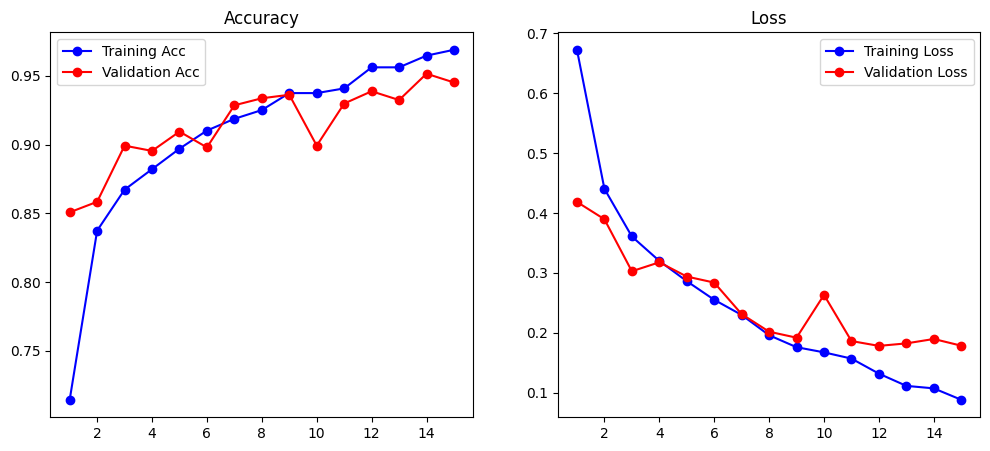

In [ ]:
#Funzione per visualizzare l'andamento del training.
#Plotta accuracy e loss per training set (blu) e validation set (rosso).

def plot_history(history):
    acc = history.history['categorical_accuracy']
    val_acc = history.history['val_categorical_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Grafico accuracy: confronto tra performance su training e validation
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Accuracy')
    plt.xlabel('Epoca')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Grafico loss: monitorare overfitting (gap crescente indica overfitting)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoca')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

plot_history(history)

25/25 [==============================] - 0s 10ms/step


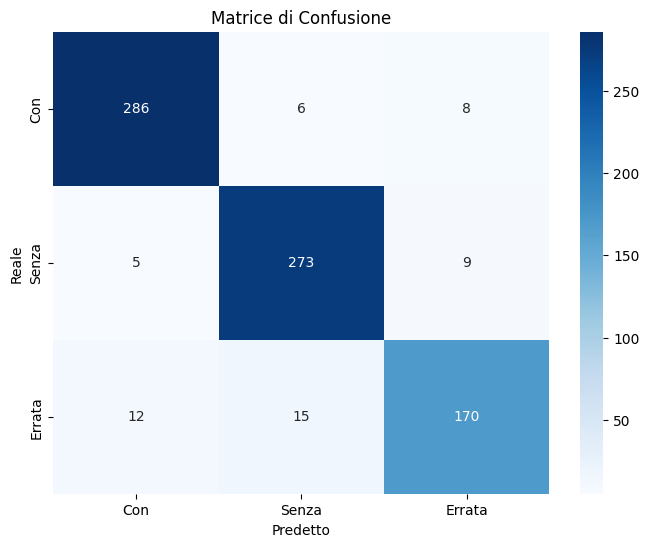

              precision    recall  f1-score   support

         Con       0.94      0.95      0.95       300
       Senza       0.93      0.95      0.94       287
      Errata       0.91      0.86      0.89       197

    accuracy                           0.93       784
   macro avg       0.93      0.92      0.92       784
weighted avg       0.93      0.93      0.93       784



In [84]:
#Generazione della matrice di confusione e report di classificazione.
#Matrice: righe = classe reale, colonne = classe predetta.
#Report: precision, recall, f1-score per ogni classe.

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Converte one-hot in indici di classe
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Con', 'Senza', 'Errata'], 
            yticklabels=['Con', 'Senza', 'Errata'])
plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.title('Matrice di Confusione')
plt.show()

#Classification report:
#- Precision: quanti positivi predetti sono corretti
#- Recall: quanti positivi reali sono stati predetti
#- F1-score: media armonica di precision e recall
print(classification_report(y_true, y_pred_classes, target_names=['Con', 'Senza', 'Errata']))

In [2]:
model = load_model("cnnMask.keras")

In [ ]:
classi = ["Mascherina errata", "Senza Mascherina", "Mascherina"]
offset=10

faces_xml = "haarcascade_frontalface_alt.xml"
face_cascade = cv2.CascadeClassifier()

# Carica classificatore
if not face_cascade.load(faces_xml):
    print('--(!)Error loading face cascade')
    exit(0)


In [ ]:
#Demo in tempo reale: rilevamento mascherine tramite webcam.
#Flow: acquisizione frame -> rilevamento volti -> preprocessing -> predizione CNN -> visualizzazione

camera = cv2.VideoCapture(0)  # 0 = webcam predefinita
if not camera.isOpened:
    print('--(!)Error opening video capture')
    exit(0)

while True:
    ret, frame = camera.read()
    if frame is None:
        print('--(!) No captured frame -- Break!')
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    # equalizeHist opzionale: migliora contrasto per rilevamento volti
    
    # Rilevamento volti con Haar Cascade
    faces = face_cascade.detectMultiScale(frame_gray)
    for (x, y, w, h) in faces:
        # Crop, resize e preprocessing del volto
        img = frame[y:y+h, x:x+h]
        img = cv2.resize(img, (64, 64))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img_to_array(img)
        img_array = img / 255.0
        img_array = np.expand_dims(img_array, axis=0)  # Aggiunge dimensione batch
        
        # Predizione del modello CNN
        prediction = model.predict(img_array)
        class_idx = np.argmax(prediction[0])
        risultato = classi[class_idx]
        print(f"Il modello dice: {risultato} con una confidenza del {prediction[0][class_idx]*100:.2f}%")
        
        # Disegno bounding box e label sul frame
        frame = cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 255), 4)
        org = (x, y - offset)
        frame = cv2.putText(frame, risultato, org, cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv2.LINE_AA)
    cv2.imshow('Capture - Face detection', frame)
    if cv2.waitKey(10) == 27:  # ESC per chiudere
        break

In [ ]:
#Demo su immagine statica: test del modello su un'immagine salvata.
#Stesso preprocessing della demo webcam.

frame = cv2.imread("C:/Users/corra/Desktop/maskDetection/test4.png")
faces = face_cascade.detectMultiScale(frame)
for (x, y, w, h) in faces:
    img = frame[y:y+h, x:x+h]
    img = cv2.resize(img, (64, 64))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img_to_array(img)
    img_array = img / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction[0])
    risultato = classi[class_idx]
    print(f"Il modello dice: {risultato} con una confidenza del {prediction[0][class_idx]*100:.2f}%")
    frame = cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 255), 4)
    org = (x, y - offset)
    frame = cv2.putText(frame, risultato, org, cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv2.LINE_AA)
cv2.imshow('Capture - Face detection', frame)
cv2.waitKey(0)  # Attende pressione di un tasto
cv2.destroyAllWindows()